In [5]:
# --- BLOQUE INICIAL ---
import os
import xarray as xr
import geopandas as gpd
import rioxarray  # si queremos recortar usando geometrías shapely
import pickle
import pandas as pd
import numpy as np


In [22]:
BASE_DIR = os.path.abspath("..")
INPUT_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
OUTPUT_DIR = INPUT_DIR  # guardamos en el mismo lugar
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

In [5]:
# Shapes
SHAPES_DIR = os.path.join(BASE_DIR, "data", "raw", "shapes")
bbi_shape = gpd.read_file(os.path.join(SHAPES_DIR, "transicion_solo.shp"))
bbii_shape = gpd.read_file(os.path.join(SHAPES_DIR, "BBII_unificado.shp"))

## PARA PH

In [6]:
# --- Parámetros del filtro físico ---
# pH superficial oceánico: rango físicamente posible en el Atlántico Sur subantártico
# Valores fuera de este rango son artefactos numéricos del modelo
PH_MIN = 7.5
PH_MAX = 8.5

In [10]:
# =============================================================================
# FUNCIÓN DE PREPROCESAMIENTO
# =============================================================================
 
def preprocess_ph(ds):
    """
    Preprocesamiento mínimo para datos de pH de CMEMS MULTIOBS.
 
    Pasos:
    1. Ordenar por tiempo
    2. Eliminar timestamps duplicados
    3. Filtro físico conservador: pH fuera de (PH_MIN, PH_MAX) → NaN
 
    No se interpolan NaN ni se aplican filtros estadísticos adicionales.
    Los NaN son manejados nativamente por xarray (skipna=True en promedios).
    """
    # 1. Ordenar tiempo
    ds = ds.sortby("time")
 
    # 2. Eliminar duplicados temporales
    ds = ds.drop_duplicates(dim="time")
 
    # 3. Filtro físico: solo sobre la variable pH
    #    El resto de variables (spco2, talk, tco2, omega) NO se filtran aquí
    #    porque tienen sus propios rangos físicos — se filtrarán si se usan
    ds["ph"] = ds["ph"].where(
        (ds["ph"] > PH_MIN) & (ds["ph"] < PH_MAX)
    )
 
    return ds

In [12]:
# =============================================================================
# APLICAR A LOS TRES ARCHIVOS
# =============================================================================
 
files = {
    "ph_BBI.nc":   "ph_BBI_ready.nc",    # series temporales — BBI (plateau)
    "ph_BBII.nc":  "ph_BBII_ready.nc",   # series temporales — BBII (slope)
    "ph_bbox.nc":  "ph_bbox_ready.nc",   # mapas de estrés — grilla completa
}
 
for input_file, output_file in files.items():
    input_path  = os.path.join(INPUT_DIR, input_file)
    output_path = os.path.join(OUTPUT_DIR, output_file)
 
    print(f"\n{'='*60}")
    print(f"Procesando: {input_file}")
 
    ds = xr.open_dataset(input_path)
 
    # Verificar NaN antes
    n_nan_before = int(ds["ph"].isnull().sum())
 
    ds_clean = preprocess_ph(ds)
 
    # Verificar NaN después
    n_nan_after = int(ds_clean["ph"].isnull().sum())
    n_filtered  = n_nan_after - n_nan_before
 
    print(f"  Dimensiones  : {dict(ds_clean.dims)}")
    print(f"  Período      : {str(ds_clean.time.values[0])[:10]} → "
          f"{str(ds_clean.time.values[-1])[:10]}")
    print(f"  NaN antes    : {n_nan_before}")
    print(f"  NaN después  : {n_nan_after}  (+{n_filtered} filtrados por rango físico)")
    print(f"  pH min/max   : {float(ds_clean['ph'].min()):.4f} / "
          f"{float(ds_clean['ph'].max()):.4f}")
 
    ds_clean.to_netcdf(output_path)
    print(f"  ✅ Guardado  : {output_file}")
 
print(f"\n{'='*60}")
print("Preprocesamiento completado.")
print(f"Archivos generados en: {OUTPUT_DIR}")
print(f"\nCriterio de filtrado documentado para el paper:")
print(f"  'Values outside the physically plausible range "
      f"({PH_MIN} < pH < {PH_MAX}) were excluded.'")


Procesando: ph_BBI.nc


C:\Users\gisel\AppData\Local\Temp\ipykernel_216748\1685443547.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensiones  : {dict(ds_clean.dims)}")
C:\Users\gisel\AppData\Local\Temp\ipykernel_216748\1685443547.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensiones  : {dict(ds_clean.dims)}")


  Dimensiones  : {'time': 480, 'latitude': 14, 'longitude': 37}
  Período      : 1985-01-01 → 2024-12-01
  NaN antes    : 217440
  NaN después  : 217440  (+0 filtrados por rango físico)
  pH min/max   : 8.0158 / 8.1649
  ✅ Guardado  : ph_BBI_ready.nc

Procesando: ph_BBII.nc
  Dimensiones  : {'time': 480, 'latitude': 14, 'longitude': 37}
  Período      : 1985-01-01 → 2024-12-01
  NaN antes    : 220800
  NaN después  : 220800  (+0 filtrados por rango físico)
  pH min/max   : 8.0228 / 8.1576
  ✅ Guardado  : ph_BBII_ready.nc

Procesando: ph_bbox.nc
  Dimensiones  : {'time': 480, 'latitude': 14, 'longitude': 37}
  Período      : 1985-01-01 → 2024-12-01
  NaN antes    : 0
  NaN después  : 0  (+0 filtrados por rango físico)
  pH min/max   : 8.0152 / 8.2006
  ✅ Guardado  : ph_bbox_ready.nc

Preprocesamiento completado.
Archivos generados en: C:\Users\gisel\BB_stress_paper\data\processed\pH

Criterio de filtrado documentado para el paper:
  'Values outside the physically plausible range (7.5 < 

C:\Users\gisel\AppData\Local\Temp\ipykernel_216748\1685443547.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"  Dimensiones  : {dict(ds_clean.dims)}")


In [13]:
print(ds.data_vars)

Data variables:
    fgco2                 (time, latitude, longitude) float32 995kB ...
    fgco2_uncertainty     (time, latitude, longitude) float32 995kB ...
    omega_ar              (time, latitude, longitude) float32 995kB ...
    omega_ar_uncertainty  (time, latitude, longitude) float32 995kB ...
    omega_ca              (time, latitude, longitude) float32 995kB ...
    omega_ca_uncertainty  (time, latitude, longitude) float32 995kB ...
    ph                    (time, latitude, longitude) float32 995kB 8.136 ......
    ph_uncertainty        (time, latitude, longitude) float32 995kB ...
    spco2                 (time, latitude, longitude) float32 995kB ...
    spco2_uncertainty     (time, latitude, longitude) float32 995kB ...
    talk                  (time, latitude, longitude) float32 995kB ...
    talk_uncertainty      (time, latitude, longitude) float32 995kB ...
    tco2                  (time, latitude, longitude) float32 995kB ...
    tco2_uncertainty      (time, latitu

In [14]:
# --- Rangos físicos por variable ---
# Basados en la distribución real de tus datos (celda 3 de 02b)
# y rangos típicos del Atlántico Sur subantártico
RANGES = {
    "ph"       : (7.5,   8.5),
    "omega_ar" : (0.5,   3.5),
    "omega_ca" : (0.8,   5.5),
    "talk"     : (2100., 2400.),
    "tco2"     : (1900., 2250.),
    "spco2"    : (100.,  700.),
    "fgco2"    : (-10.,  10.),   # mol/m²/año, puede ser negativo (sumidero)
}
# Las variables de incertidumbre (_uncertainty) no se filtran

def preprocess_dataset(ds):
    """
    Preprocesamiento mínimo para todas las variables del producto
    CMEMS MULTIOBS.

    Pasos:
    1. Ordenar por tiempo
    2. Eliminar timestamps duplicados
    3. Filtro físico conservador por variable → NaN fuera del rango

    Las variables de incertidumbre (_uncertainty) no se filtran —
    su rango depende del modelo y no tiene interpretación física directa.
    """
    # 1. Ordenar tiempo
    ds = ds.sortby("time")

    # 2. Eliminar duplicados temporales
    ds = ds.drop_duplicates(dim="time")

    # 3. Filtro físico por variable
    for var, (vmin, vmax) in RANGES.items():
        if var in ds:
            n_before = int(ds[var].isnull().sum())
            ds[var]  = ds[var].where((ds[var] > vmin) & (ds[var] < vmax))
            n_after  = int(ds[var].isnull().sum())
            if n_after > n_before:
                print(f"    {var}: {n_after - n_before} valores filtrados")

    return ds


# --- Aplicar a los tres archivos ---
files = {
    "ph_BBI.nc"  : "ph_BBI_ready.nc",
    "ph_BBII.nc" : "ph_BBII_ready.nc",
    "ph_bbox.nc" : "ph_bbox_ready.nc",
}

for input_file, output_file in files.items():
    input_path  = os.path.join(INPUT_DIR, input_file)
    output_path = os.path.join(OUTPUT_DIR, output_file)

    print(f"\n{'='*60}")
    print(f"Procesando: {input_file}")

    ds       = xr.open_dataset(input_path)
    ds_clean = preprocess_dataset(ds)

    print(f"  Período : {str(ds_clean.time.values[0])[:10]} → "
          f"{str(ds_clean.time.values[-1])[:10]}")
    print(f"  ✅ Guardado: {output_file}")

    ds_clean.to_netcdf(output_path)

print(f"\n{'='*60}")
print("Preprocesamiento completado.")
print("\nCriterios de filtrado documentados para el paper:")
for var, (vmin, vmax) in RANGES.items():
    print(f"  {var}: ({vmin}, {vmax})")


Procesando: ph_BBI.nc
  Período : 1985-01-01 → 2024-12-01
  ✅ Guardado: ph_BBI_ready.nc

Procesando: ph_BBII.nc
  Período : 1985-01-01 → 2024-12-01
  ✅ Guardado: ph_BBII_ready.nc

Procesando: ph_bbox.nc
  Período : 1985-01-01 → 2024-12-01
  ✅ Guardado: ph_bbox_ready.nc

Preprocesamiento completado.

Criterios de filtrado documentados para el paper:
  ph: (7.5, 8.5)
  omega_ar: (0.5, 3.5)
  omega_ca: (0.8, 5.5)
  talk: (2100.0, 2400.0)
  tco2: (1900.0, 2250.0)
  spco2: (100.0, 700.0)
  fgco2: (-10.0, 10.0)


#### Para validar datos con glodap

In [7]:
import pandas as pd

glodap_path = r"G:/Mi unidad/CIC/DATOS/Glodap/GLODAPv22022AtlanticOcean.csv"
df_glodap = pd.read_csv(glodap_path, comment="#")
print(df_glodap.columns.tolist())
print(df_glodap.head(3))

['G2expocode', 'G2cruise', 'G2station', 'G2region', 'G2cast', 'G2year', 'G2month', 'G2day', 'G2hour', 'G2minute', 'G2latitude', 'G2longitude', 'G2bottomdepth', 'G2maxsampdepth', 'G2bottle', 'G2pressure', 'G2depth', 'G2temperature', 'G2theta', 'G2salinity', 'G2salinityf', 'G2salinityqc', 'G2sigma0', 'G2sigma1', 'G2sigma2', 'G2sigma3', 'G2sigma4', 'G2gamma', 'G2oxygen', 'G2oxygenf', 'G2oxygenqc', 'G2aou', 'G2aouf', 'G2nitrate', 'G2nitratef', 'G2nitrateqc', 'G2nitrite', 'G2nitritef', 'G2silicate', 'G2silicatef', 'G2silicateqc', 'G2phosphate', 'G2phosphatef', 'G2phosphateqc', 'G2tco2', 'G2tco2f', 'G2tco2qc', 'G2talk', 'G2talkf', 'G2talkqc', 'G2fco2', 'G2fco2f', 'G2fco2temp', 'G2phts25p0', 'G2phts25p0f', 'G2phtsinsitutp', 'G2phtsinsitutpf', 'G2phtsqc', 'G2cfc11', 'G2pcfc11', 'G2cfc11f', 'G2cfc11qc', 'G2cfc12', 'G2pcfc12', 'G2cfc12f', 'G2cfc12qc', 'G2cfc113', 'G2pcfc113', 'G2cfc113f', 'G2cfc113qc', 'G2ccl4', 'G2pccl4', 'G2ccl4f', 'G2ccl4qc', 'G2sf6', 'G2psf6', 'G2sf6f', 'G2sf6qc', 'G2c13', '

In [8]:
# Filtrar por área del BB y capa superficial
df_bb = df_glodap[
    (df_glodap["G2latitude"]  >= -56) & (df_glodap["G2latitude"]  <= -52) &
    (df_glodap["G2longitude"] >= -64) & (df_glodap["G2longitude"] <= -54) &
    (df_glodap["G2depth"]     <= 10)   # solo superficie
].copy()

print(f"Registros en el BB superficie: {len(df_bb)}")

# Ver qué variables tienen datos válidos (no -9999)
for var in ["G2tco2", "G2talk", "G2phtsinsitutp", "G2phts25p0"]:
    valid = (df_bb[var] != -9999).sum()
    print(f"  {var}: {valid} registros válidos")

Registros en el BB superficie: 44
  G2tco2: 10 registros válidos
  G2talk: 9 registros válidos
  G2phtsinsitutp: 9 registros válidos
  G2phts25p0: 9 registros válidos


In [9]:
df_valid = df_bb[df_bb["G2phtsinsitutp"] != -9999][
    ["G2year", "G2month", "G2latitude", "G2longitude", 
     "G2depth", "G2phtsinsitutp", "G2tco2", "G2talk"]
].copy()

print(df_valid.to_string(index=False))

 G2year  G2month  G2latitude  G2longitude  G2depth  G2phtsinsitutp  G2tco2  G2talk
   2009        2     -55.834      -57.807      9.0          8.0979  2095.7  2277.7
   2009        2     -55.214      -58.000      6.0          8.0639  2099.6  2267.5
   2009        2     -55.121      -57.999      7.0          8.0943  2092.2  2275.0
   2009        2     -55.007      -57.996      6.0          8.0924  2094.3  2277.8
   2009        2     -54.922      -58.000      5.0          8.0906  2093.6  2275.6
   2009        2     -54.667      -58.000      5.0          8.0713  2093.6  2266.8
   2009        2     -53.981      -58.000      5.0          8.0763  2092.9  2270.9
   2009        2     -53.520      -58.000      6.0          8.0736  2088.8  2269.5
   2009        2     -53.133      -57.996      6.0          8.1060  2078.4  2274.6


In [12]:
import xarray as xr

ds_cmems = xr.open_dataset(os.path.join(BASE_DIR, "data", "processed", "pH", "ph_bbox_ready.nc"))

# Seleccionar febrero 2009
ds_feb2009 = ds_cmems.sel(time="2009-02-01")

comparisons = []
for _, row in df_valid.iterrows():
    # Seleccionar el píxel más cercano
    ph_cmems = float(ds_feb2009["ph"].sel(
        latitude=row["G2latitude"],
        longitude=row["G2longitude"],
        method="nearest"
    ).values)
    
    comparisons.append({
        "lat"          : row["G2latitude"],
        "lon"          : row["G2longitude"],
        "pH_GLODAP"    : row["G2phtsinsitutp"],
        "pH_CMEMS"     : ph_cmems,
        "diff"         : ph_cmems - row["G2phtsinsitutp"],
    })

df_comp = pd.DataFrame(comparisons)
print(df_comp.to_string(index=False))
print(f"\nBias medio (CMEMS - GLODAP): {df_comp['diff'].mean():.4f}")
print(f"RMSD                       : {(df_comp['diff']**2).mean()**0.5:.4f}")
print(f"r                          : {df_comp['pH_GLODAP'].corr(df_comp['pH_CMEMS']):.4f}")

    lat     lon  pH_GLODAP  pH_CMEMS      diff
-55.834 -57.807     8.0979  8.072672 -0.025228
-55.214 -58.000     8.0639  8.076159  0.012259
-55.121 -57.999     8.0943  8.076159 -0.018141
-55.007 -57.996     8.0924  8.076159 -0.016241
-54.922 -58.000     8.0906  8.075864 -0.014736
-54.667 -58.000     8.0713  8.077611  0.006311
-53.981 -58.000     8.0763  8.078157  0.001857
-53.520 -58.000     8.0736  8.079736  0.006136
-53.133 -57.996     8.1060  8.082918 -0.023082

Bias medio (CMEMS - GLODAP): -0.0079
RMSD                       : 0.0157
r                          : 0.0485


Resultados de la validación
Bias medio: -0.008 pH → CMEMS subestima levemente el pH observado. Muy pequeño y comparable al bias del CMIP6 (+0.008). Prácticamente despreciable.
RMSD: 0.016 pH → excelente para un producto de reanálisis a 0.25° comparado contra datos puntuales in situ.
r: 0.05 → correlación casi nula. Esto es lo que hay que explicar bien.

Por qué r es tan bajo
No es un problema del producto — es un problema de escala. Tus 9 puntos están todos en el mismo mes (febrero 2009) y en un rango de pH muy estrecho (8.06–8.11, solo 0.05 unidades de variación). Con tan poca variabilidad y tan pocos puntos, la correlación no tiene sentido estadístico. Un revisor lo va a señalar.
La métrica relevante acá es el bias y el RMSD, no la correlación. La correlación es informativa cuando tenés variabilidad temporal — con 9 puntos del mismo mes no aplica.

Cómo reportarlo en el paper

"Regional validation against GLODAPv2 in situ pH measurements within the study area (n=9, February 2009) yielded a mean bias of −0.008 pH units and an RMSD of 0.016 pH units, consistent with the global validation reported in the product quality documentation (QUID). The low sample size precludes meaningful correlation analysis; however, the bias and RMSD are within the uncertainty range of the product (ph_uncertainty mean ~0.01)."

In [15]:
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

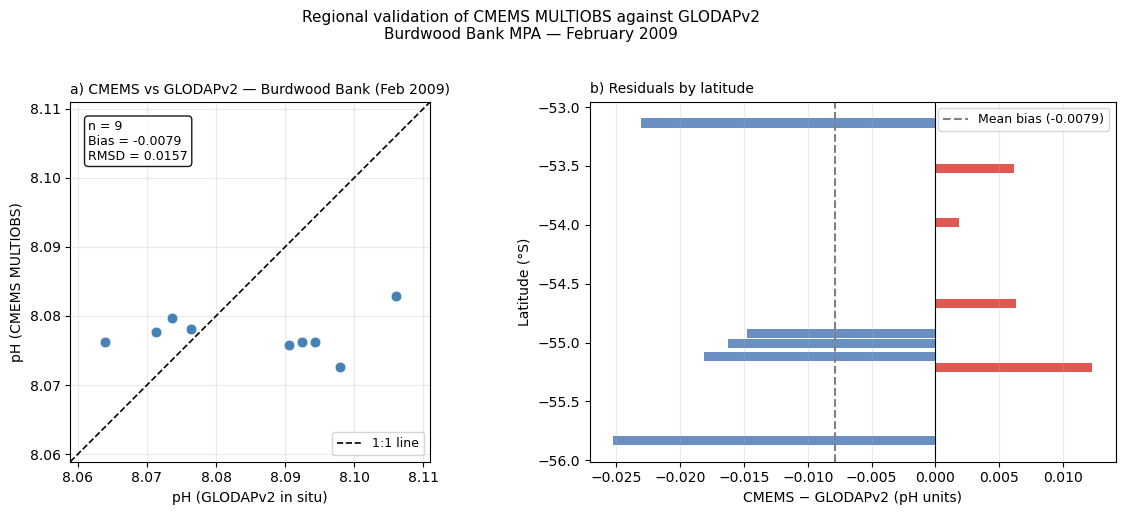

✅ FigS_validation.png guardada


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
# df_comp ya está calculado en la celda anterior
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# =============================================================================
# Panel 1: Scatter GLODAP vs CMEMS
# =============================================================================
ax = axes[0]
 
ax.scatter(df_comp["pH_GLODAP"], df_comp["pH_CMEMS"],
           color="steelblue", s=60, zorder=3, edgecolors="white", lw=0.5)
 
# Línea 1:1
lim_min = min(df_comp["pH_GLODAP"].min(), df_comp["pH_CMEMS"].min()) - 0.005
lim_max = max(df_comp["pH_GLODAP"].max(), df_comp["pH_CMEMS"].max()) + 0.005
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        color="black", lw=1.2, linestyle="--", label="1:1 line", zorder=2)
 
# Estadísticas
bias = df_comp["diff"].mean()
rmsd = (df_comp["diff"]**2).mean()**0.5
ax.text(0.05, 0.95,
        f"n = {len(df_comp)}\nBias = {bias:+.4f}\nRMSD = {rmsd:.4f}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9))
 
ax.set_xlabel("pH (GLODAPv2 in situ)", fontsize=10)
ax.set_ylabel("pH (CMEMS MULTIOBS)", fontsize=10)
ax.set_title("a) CMEMS vs GLODAPv2 — Burdwood Bank (Feb 2009)",
             fontsize=10, loc="left")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.set_aspect("equal")
 
# =============================================================================
# Panel 2: Diferencias por latitud
# =============================================================================
ax = axes[1]
 
ax.barh(df_comp["lat"], df_comp["diff"],
        color=["#d73027" if d > 0 else "#4575b4" for d in df_comp["diff"]],
        alpha=0.8, height=0.08)
ax.axvline(0,    color="black", lw=0.8)
ax.axvline(bias, color="gray",  lw=1.5, linestyle="--",
           label=f"Mean bias ({bias:+.4f})")
 
ax.set_xlabel("CMEMS − GLODAPv2 (pH units)", fontsize=10)
ax.set_ylabel("Latitude (°S)", fontsize=10)
ax.set_title("b) Residuals by latitude",
             fontsize=10, loc="left")
ax.legend(fontsize=9)
ax.grid(alpha=0.25, axis="x")
 
plt.suptitle(
    "Regional validation of CMEMS MULTIOBS against GLODAPv2\n"
    "Burdwood Bank MPA — February 2009",
    fontsize=11, y=1.02
)
 
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "FigS_validation.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ FigS_validation.png guardada")
 

In [17]:
ds_soda = xr.open_dataset(r"G:\Mi unidad\CIC\DATOS\Datos OceanSODA 2022\completo hasta 2023\OceanSODA_ETHZ-v2023.OCADS.01_1982-2022.nc")
print(ds_soda)

<xarray.Dataset> Size: 3GB
Dimensions:          (time: 492, lat: 180, lon: 360, region: 4)
Coordinates:
  * time             (time) datetime64[ns] 4kB 1982-01-15 ... 2022-12-15
  * lat              (lat) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * lon              (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * region           (region) <U7 112B 'global' 'north' 'tropics' 'south'
Data variables: (12/28)
    talk             (time, lat, lon) float32 128MB ...
    dic              (time, lat, lon) float32 128MB ...
    spco2            (time, lat, lon) float32 128MB ...
    sfco2            (time, lat, lon) float32 128MB ...
    ph_total         (time, lat, lon) float32 128MB ...
    ph_free          (time, lat, lon) float32 128MB ...
    ...               ...
    area             (lat, lon) float32 259kB ...
    fgco2_reg        (region, time) float32 8kB ...
    area_reg         (region) float32 16B ...
    ice              (time, lat, lon) float32 128MB ...
    kw 

In [24]:
import os
import numpy as np
import pandas as pd
import xarray as xr

BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

# --- CMEMS ---
ds_BBI  = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBI_ready.nc"))
ds_BBII = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBII_ready.nc"))

def weighted_mean_ds(ds, var):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return ds[var].weighted(weights).mean(
        dim=["latitude","longitude"], skipna=True)

ph_combined = (weighted_mean_ds(ds_BBI, "ph") + weighted_mean_ds(ds_BBII, "ph")) / 2
df_obs = ph_combined.to_dataframe(name="pH").reset_index()
df_obs["time"] = pd.to_datetime(df_obs["time"])
df_obs["year"] = df_obs["time"].dt.year

# --- OceanSODA ---
ds_soda    = xr.open_dataset(r"G:\Mi unidad\CIC\DATOS\Datos OceanSODA 2022\completo hasta 2023\OceanSODA_ETHZ-v2023.OCADS.01_1982-2022.nc")
ds_soda_bb = ds_soda["ph_total"].sel(lat=slice(-56, -52), lon=slice(-64, -54))
weights    = np.cos(np.deg2rad(ds_soda_bb.lat))
ph_soda    = ds_soda_bb.weighted(weights).mean(dim=["lat", "lon"], skipna=True)
df_soda    = ph_soda.to_dataframe(name="pH_soda").reset_index()
df_soda["time"] = pd.to_datetime(df_soda["time"])
df_soda["year"] = df_soda["time"].dt.year

# --- Comparación período solapado 1985-2022 ---
df_cmems_overlap = df_obs[df_obs["year"].between(1985, 2022)]
df_soda_overlap  = df_soda[df_soda["year"].between(1985, 2022)]

print(f"pH medio CMEMS BB     : {df_cmems_overlap['pH'].mean():.4f}")
print(f"pH medio OceanSODA BB : {df_soda_overlap['pH_soda'].mean():.4f}")
print(f"Diferencia            : {df_cmems_overlap['pH'].mean() - df_soda_overlap['pH_soda'].mean():+.4f}")

pH medio CMEMS BB     : 8.0792
pH medio OceanSODA BB : 8.1036
Diferencia            : -0.0244


In [25]:
# Merge por mes para comparar punto a punto
df_cmems_m = df_obs[df_obs["year"].between(1985, 2022)][["time", "pH"]].copy()
df_soda_m  = df_soda[df_soda["year"].between(1985, 2022)][["time", "pH_soda"]].copy()

# Redondear tiempo al mes para hacer merge
df_cmems_m["time"] = df_cmems_m["time"].dt.to_period("M").dt.to_timestamp()
df_soda_m["time"]  = df_soda_m["time"].dt.to_period("M").dt.to_timestamp()

df_merged = pd.merge(df_cmems_m, df_soda_m, on="time")
df_merged["diff"] = df_merged["pH"] - df_merged["pH_soda"]

print(f"N meses comparados : {len(df_merged)}")
print(f"Bias medio         : {df_merged['diff'].mean():+.4f}")
print(f"RMSD               : {(df_merged['diff']**2).mean()**0.5:.4f}")
print(f"Correlación r      : {df_merged['pH'].corr(df_merged['pH_soda']):.4f}")
print(f"\nDiferencia por período:")
for y1, y2 in [(1985,1995), (1996,2005), (2006,2015), (2016,2022)]:
    sub = df_merged[df_merged["time"].dt.year.between(y1, y2)]
    print(f"  {y1}–{y2}: {sub['diff'].mean():+.4f}")

N meses comparados : 456
Bias medio         : -0.0244
RMSD               : 0.0256
Correlación r      : 0.9482

Diferencia por período:
  1985–1995: -0.0278
  1996–2005: -0.0241
  2006–2015: -0.0230
  2016–2022: -0.0216


Lo que dicen los números
Correlación r = 0.948 → ambos productos capturan exactamente la misma variabilidad temporal — son muy consistentes en tendencias y estacionalidad. Esto es lo más importante.
Bias estable ~-0.024 → CMEMS es sistemáticamente más bajo que OceanSODA en todo el período. No es aleatorio — es un offset metodológico entre los dos productos.
El bias decrece levemente con el tiempo (-0.028 → -0.022) → los productos se van acercando en los años más recientes, probablemente porque hay más datos de entrenamiento disponibles para ambos.

¿Es esto un problema?
No necesariamente. Un offset sistemático entre dos productos construidos con metodologías distintas es completamente normal y esperado. Lo importante es que:

Las tendencias son consistentes (r = 0.948) → ambos muestran la misma acidificación
El bias es estable → no afecta el análisis de tendencias ni el CUSUM
El bias con GLODAP in situ es mucho menor (-0.008) → sugiere que CMEMS está más cerca de la realidad que OceanSODA en esta región



### Figura de comparacion con OCEAN soda

In [35]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

BASE_DIR      = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed", "pH")
FIGURES_DIR   = os.path.join(BASE_DIR, "figures")

plt.rcParams.update({
    "font.size": 10, "axes.titlesize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

# =============================================================================
# CELDA 1 — Cargar y preparar series temporales
# =============================================================================

# --- CMEMS ---
ds_BBI  = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBI_ready.nc"))
ds_BBII = xr.open_dataset(os.path.join(PROCESSED_DIR, "ph_BBII_ready.nc"))

def weighted_mean_ds(ds, var):
    weights = np.cos(np.deg2rad(ds["latitude"]))
    return ds[var].weighted(weights).mean(
        dim=["latitude","longitude"], skipna=True)

ph_combined = (weighted_mean_ds(ds_BBI, "ph") + weighted_mean_ds(ds_BBII, "ph")) / 2
df_cmems = ph_combined.to_dataframe(name="pH").reset_index()
df_cmems["time"] = pd.to_datetime(df_cmems["time"])
df_cmems["year"] = df_cmems["time"].dt.year

# --- OceanSODA-ETHZ ---
ds_soda    = xr.open_dataset(
    r"G:\Mi unidad\CIC\DATOS\Datos OceanSODA 2022\completo hasta 2023"
    r"\OceanSODA_ETHZ-v2023.OCADS.01_1982-2022.nc"
)
ds_soda_bb = ds_soda["ph_total"].sel(
    lat=slice(-56, -52), lon=slice(-64, -54)
)
weights  = np.cos(np.deg2rad(ds_soda_bb.lat))
ph_soda  = ds_soda_bb.weighted(weights).mean(dim=["lat", "lon"], skipna=True)
df_soda  = ph_soda.to_dataframe(name="pH").reset_index()
df_soda["time"] = pd.to_datetime(df_soda["time"])
df_soda["year"] = df_soda["time"].dt.year

# --- Período solapado ---
df_cmems_ov = df_cmems[df_cmems["year"].between(1985, 2022)].copy()
df_soda_ov  = df_soda[df_soda["year"].between(1985, 2022)].copy()

# Merge mensual
df_cmems_ov["time_m"] = df_cmems_ov["time"].dt.to_period("M").dt.to_timestamp()
df_soda_ov["time_m"]  = df_soda_ov["time"].dt.to_period("M").dt.to_timestamp()
df_merged = pd.merge(
    df_cmems_ov[["time_m","pH"]].rename(columns={"pH":"pH_cmems"}),
    df_soda_ov[["time_m","pH"]].rename(columns={"pH":"pH_soda"}),
    on="time_m"
)
df_merged["diff"] = df_merged["pH_cmems"] - df_merged["pH_soda"]

# --- Tendencias STL ---
def get_stl_trend(times, values):
    idx = pd.to_datetime(times).to_period("M").to_timestamp()
    series = pd.Series(values, index=idx)
    series = series[~series.index.duplicated()]
    series = series.asfreq("MS")
    result = STL(series, period=12, robust=True).fit()
    trend  = result.trend.values
    return trend, series.index  # retornar también el índice

trend_cmems, idx_cmems = get_stl_trend(df_cmems_ov["time"].values, df_cmems_ov["pH"].values)
trend_soda,  idx_soda  = get_stl_trend(df_soda_ov["time"].values,  df_soda_ov["pH"].values)

# Estadísticas
bias = df_merged["diff"].mean()
rmsd = (df_merged["diff"]**2).mean()**0.5
r    = df_merged["pH_cmems"].corr(df_merged["pH_soda"])

print(f"N meses: {len(df_merged)}, Bias: {bias:+.4f}, RMSD: {rmsd:.4f}, r: {r:.4f}")



N meses: 456, Bias: -0.0244, RMSD: 0.0256, r: 0.9482


In [40]:
import matplotlib.dates as mdates

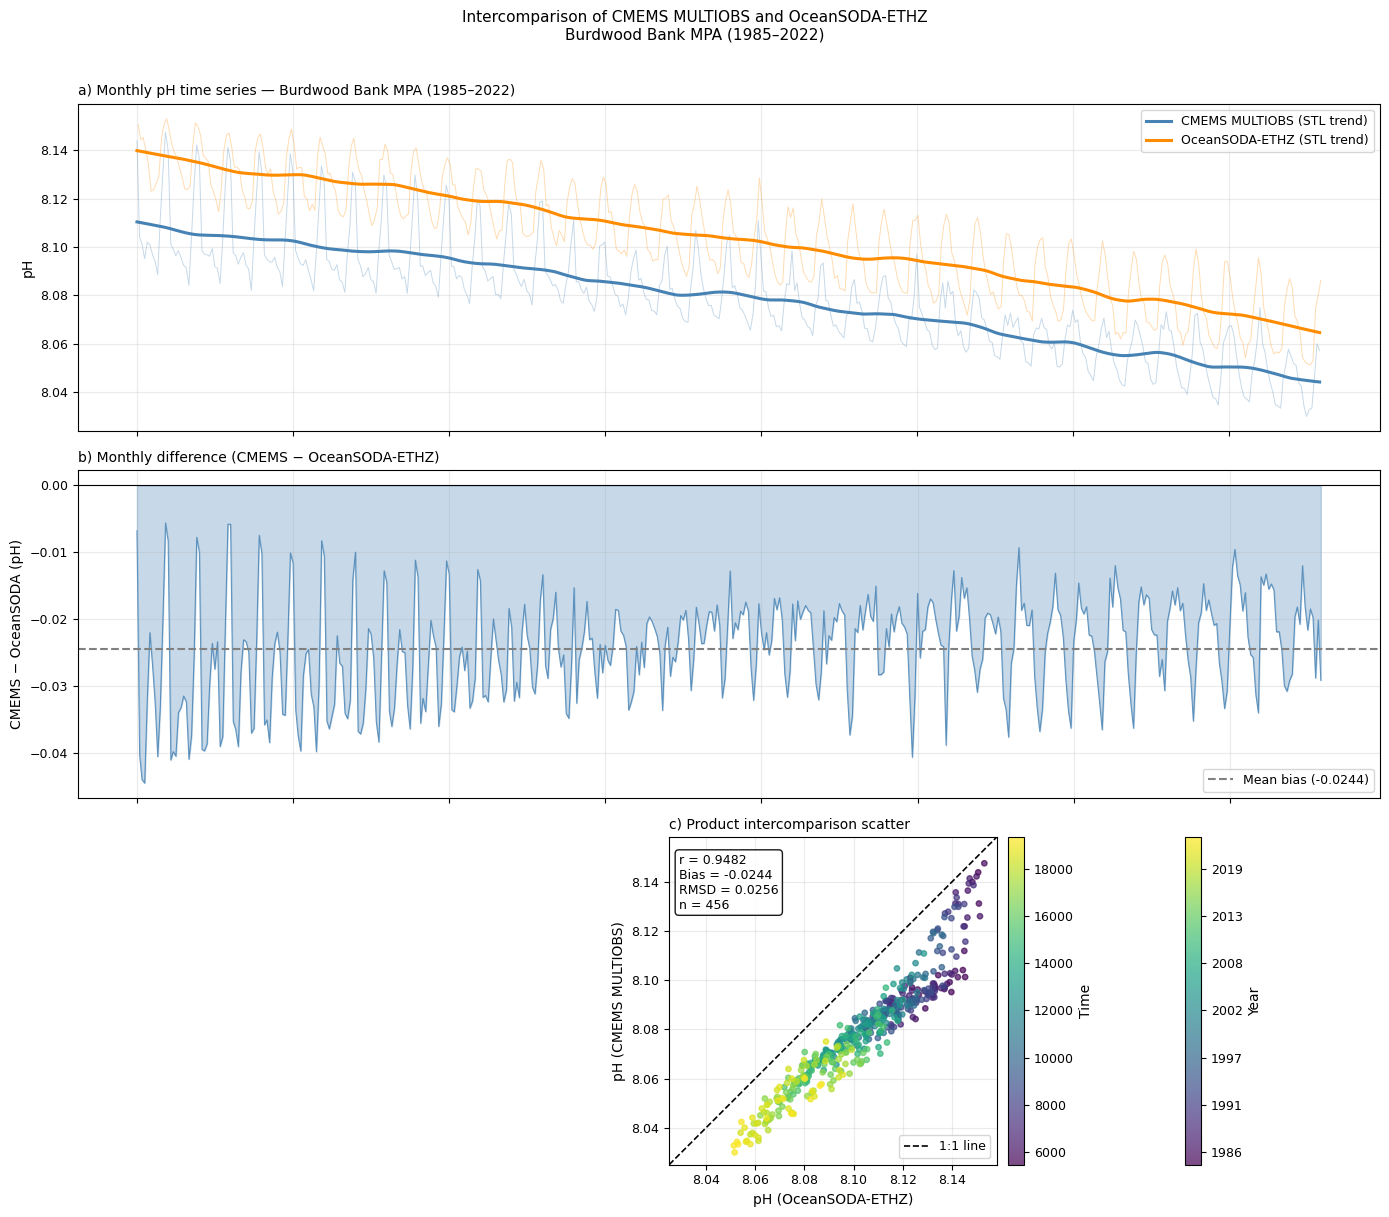

✅ FigS_OceanSODA_comparison.png guardada


In [41]:
# =============================================================================
# CELDA 2 — Figura: 3 paneles
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

times_cmems = df_cmems_ov["time"].values
times_soda  = df_soda_ov["time"].values

# --- Panel a: series mensuales + tendencias STL ---
ax = axes[0]
ax.plot(times_cmems, df_cmems_ov["pH"].values,
        color="steelblue", alpha=0.3, lw=0.7)
ax.plot(idx_cmems, trend_cmems,
        color="steelblue", lw=2.2, label="CMEMS MULTIOBS (STL trend)")

ax.plot(times_soda, df_soda_ov["pH"].values,
        color="darkorange", alpha=0.3, lw=0.7)
ax.plot(idx_soda, trend_soda,
        color="darkorange", lw=2.2, label="OceanSODA-ETHZ (STL trend)")
    
ax.set_ylabel("pH", fontsize=10)
ax.set_title("a) Monthly pH time series — Burdwood Bank MPA (1985–2022)",
             fontsize=10, loc="left")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xticklabels([])

# --- Panel b: diferencia mensual CMEMS - OceanSODA ---
ax = axes[1]

ax.plot(df_merged["time_m"], df_merged["diff"],
        color="steelblue", lw=0.8, alpha=0.8)
ax.fill_between(df_merged["time_m"], df_merged["diff"], 0,
                alpha=0.3, color="steelblue")

ax.axhline(0,    color="black", lw=0.8)
ax.axhline(bias, color="gray",  lw=1.5, linestyle="--",
           label=f"Mean bias ({bias:+.4f})")
ax.set_ylabel("CMEMS − OceanSODA (pH)", fontsize=10)
ax.set_title("b) Monthly difference (CMEMS − OceanSODA-ETHZ)",
             fontsize=10, loc="left")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xticklabels([])

# --- Panel c: scatter ---
ax = axes[2]

sc = ax.scatter(df_merged["pH_soda"], df_merged["pH_cmems"],
                c=mdates.date2num(pd.to_datetime(df_merged["time_m"])),
                cmap="viridis", s=15, alpha=0.7, zorder=3)
cbar = plt.colorbar(sc, ax=ax, label="Year", pad=0.01)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: str(mdates.num2date(x).year))
)

# Línea 1:1
lim = [min(df_merged["pH_soda"].min(), df_merged["pH_cmems"].min()) - 0.005,
       max(df_merged["pH_soda"].max(), df_merged["pH_cmems"].max()) + 0.005]
ax.plot(lim, lim, color="black", lw=1.2, linestyle="--", label="1:1 line")

ax.text(0.03, 0.95,
        f"r = {r:.4f}\nBias = {bias:+.4f}\nRMSD = {rmsd:.4f}\nn = {len(df_merged)}",
        transform=ax.transAxes, fontsize=9, va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9))

plt.colorbar(sc, ax=ax, label="Time", pad=0.01)
ax.set_xlabel("pH (OceanSODA-ETHZ)", fontsize=10)
ax.set_ylabel("pH (CMEMS MULTIOBS)", fontsize=10)
ax.set_title("c) Product intercomparison scatter",
             fontsize=10, loc="left")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect("equal")

plt.suptitle(
    "Intercomparison of CMEMS MULTIOBS and OceanSODA-ETHZ\n"
    "Burdwood Bank MPA (1985–2022)",
    fontsize=11, y=1.01
)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "FigS_OceanSODA_comparison.png"),
            dpi=300, bbox_inches="tight")
plt.show()
print("✅ FigS_OceanSODA_comparison.png guardada")

In [ ]:
print(f"CMEMS : {len(df_cmems_ov)} meses, {df_cmems_ov['time'].iloc[0].date()} → {df_cmems_ov['time'].iloc[-1].date()}")
print(f"SODA  : {len(df_soda_ov)} meses, {df_soda_ov['time'].iloc[0].date()} → {df_soda_ov['time'].iloc[-1].date()}")